# CIFAR Image Generator on Google Colab

This notebook allows you to train and test the **CIFAR Image Generator** on Google Colab's infrastructure (GPU recommended).

### Check GPU Availability

In [1]:
!nvidia-smi

Mon Feb 16 07:19:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   40C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Setting Up the Workspace

In [2]:
# 2. Mount Drive and Setup Repository
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define paths
drive_path = "/content/drive/MyDrive/" # You can change this path
user = "Bhavikupadhyay"
repo = "cifar-image-generator"
repo_full_path = os.path.join(drive_path, repo)

# Create the base directory if it doesn't exist
if not os.path.exists(drive_path):
    os.makedirs(drive_path)

# Navigate to Drive path
%cd {drive_path}

if not os.path.exists(repo):
    print(f"Cloning {repo} into Drive for the first time...")
    # NOTE: If the repo is PRIVATE, you must use a token:
    # !git clone https://YOUR_TOKEN_HERE@github.com/{user}/{repo}.git
    !git clone https://github.com/{user}/{repo}.git
else:
    print(f"Repository already exists at {repo_full_path}. Pulling latest changes...")
    %cd {repo}
    !git pull

# Ensure we are inside the repo directory
%cd {repo_full_path}

Mounted at /content/drive
/content/drive/MyDrive
Repository already exists at /content/drive/MyDrive/cifar-image-generator. Pulling latest changes...
/content/drive/MyDrive/cifar-image-generator
Already up to date.
/content/drive/MyDrive/cifar-image-generator


### Install Dependencies

In [3]:
# For Colab, only need to install wandb. 
%pip install wandb

### Run the training loop

In [6]:
# Creates a new run in runs
# You can modify hyperparameters here if needed by importing Config

from src import Config
from train import train
import torch

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

# Create a config for a short run using GPU
cfg = Config(
    use_wandb=True        # Set to True if you want to login to wandb
)

print("Starting training on Colab...")
print("="*30, "\n")
train(cfg)

PyTorch Version: 2.9.0+cu128
CUDA Available: True
Starting training on Colab...

Directory Structure created at: /content/drive/MyDrive/cifar-image-generator/runs/2026-02-16_07-27-22
Config saved to /content/drive/MyDrive/cifar-image-generator/runs/2026-02-16_07-27-22/config.yaml
Starting Run: 2026-02-16_07-27-22
Device: cuda
Logs: /content/drive/MyDrive/cifar-image-generator/runs/2026-02-16_07-27-22/logs


Total Parameters: 93,859,843
Trainable Parameters: 93,859,843


Sampling : 100%|██████████| 1000/1000 [00:15<00:00, 62.98it/s]


batch_loss,█▆▅▆▄▆▅▄▅▆▅▃▃▅▃▅▄▄▃▄▁▄▄▃▅▄▁▃▃▂▃▃▂▁▁▂▁▄▂▃
epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇████
epoch_duration_sec,▄▄▃▅▇█▆▇▆▇▇▇▇█▇▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▇▇▇▅▇
global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇██
gpu_memory_allocated_gb,█████▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
gpu_memory_reserved_gb,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
grad_norm,█▄▃▃▅▃▃▃▃▆▃▃▃▄▂▂▂▃▂▁▂▂▂▂▂▂▁▂▂▂▂▁▂▁▁▁▁▂▁▂
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▇▆▆▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_max,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+1,...


### Inference

In [7]:
timestamp = '2026-02-16_07-27-22' # obtain from the above cell
!python inference.py --run_name {timestamp} --num_samples 64 --device cuda

Loaded config from: /content/drive/MyDrive/cifar-image-generator/runs/2026-02-16_07-27-22
Device: cuda
Loading latest checkpoint: ckpt_epoch_100.pth
Generating 64 samples...
Sampling : 100% 1000/1000 [00:56<00:00, 17.71it/s]
Saved sample grid to: /content/drive/MyDrive/cifar-image-generator/runs/2026-02-16_07-27-22/inference/inference_sample.png


### Visualize the Results

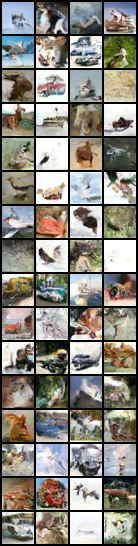

In [8]:
import os
from IPython.display import Image, display

img_path = f'runs/{timestamp}/inference/inference_sample.png'
if os.path.exists(img_path):
    display(Image(filename=img_path))
else:
    print("Image not found. Check if inference ran successfully.")